모듈화한거 쓰기위한 파일인데 뭐가 바뀌었느지 봐라

In [ ]:
CURRENT_NOTEBOOK_FILENAME = "titanic_machin_learning_module 4.ipynb"

# Load Dataset

In [1]:
from common.modeling import Modeling

import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

from common.utils import train_test_split_by_target
from common.modeling import CAT_COLS

import category_encoders as ce #오버 샘플링하려면 인코딩해야하니까
from imblearn.over_sampling import SMOTE # 이건 오버 샘플링 연습삼아 하는거임. 

In [2]:
train = pd.read_csv(r"C:\dev\kaggle_competition\titanic_real\data\train.csv")
test = pd.read_csv(r"C:\dev\kaggle_competition\titanic_real\data\test.csv")

In [3]:
train_train, train_test = train_test_split_by_target(train, target_name='survived')

## Target

In [4]:
train.shape

(916, 12)

In [5]:
train.columns 

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [6]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]
# 이진분류, 언밸런스 

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# EDA

In [7]:
train_train.info()

<class 'pandas.DataFrame'>
Index: 687 entries, 595 to 636
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  687 non-null    int64  
 1   survived     687 non-null    int64  
 2   pclass       687 non-null    int64  
 3   name         687 non-null    str    
 4   gender       687 non-null    str    
 5   age          561 non-null    float64
 6   sibsp        687 non-null    int64  
 7   parch        687 non-null    int64  
 8   ticket       687 non-null    str    
 9   fare         687 non-null    float64
 10  cabin        144 non-null    str    
 11  embarked     687 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 69.8 KB


In [8]:
train_num = train.select_dtypes(include=np.number)
train_num.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,916.000000,916.000000,916.000000,736.000000,916.000000,916.000000,916.000000
mean,457.500000,0.377729,2.292576,29.698370,0.507642,0.361354,32.402710
std,264.570721,0.485084,0.838675,14.185627,1.044866,0.828054,50.506411
min,0.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,228.750000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,457.500000,0.000000,3.000000,28.000000,0.000000,0.000000,14.458300
75%,686.250000,1.000000,3.000000,38.000000,1.000000,0.000000,30.017700
max,915.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [9]:
train_str = train.select_dtypes(exclude=np.number)
train_str.describe()

,name,gender,ticket,cabin,embarked
count,916,916,916,198,915
unique,915,2,703,146,3
top,"Connolly, Miss. Kate",male,CA. 2343,B57 B59 B63 B66,S
freq,2,589,7,4,645


In [10]:
train['survived'].value_counts() / len(train)

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

In [11]:
train['embarked'].value_counts() #얘는 인코딩 하기 쉬우니까 인코딩 해보자.

embarked
S    645
C    189
Q     81
Name: count, dtype: int64

In [12]:
# 필요없는 컬럼 제거
# train.drop(
#     ['name', 'ticket'], axis=1, inplace=True
# )

# train.shape 

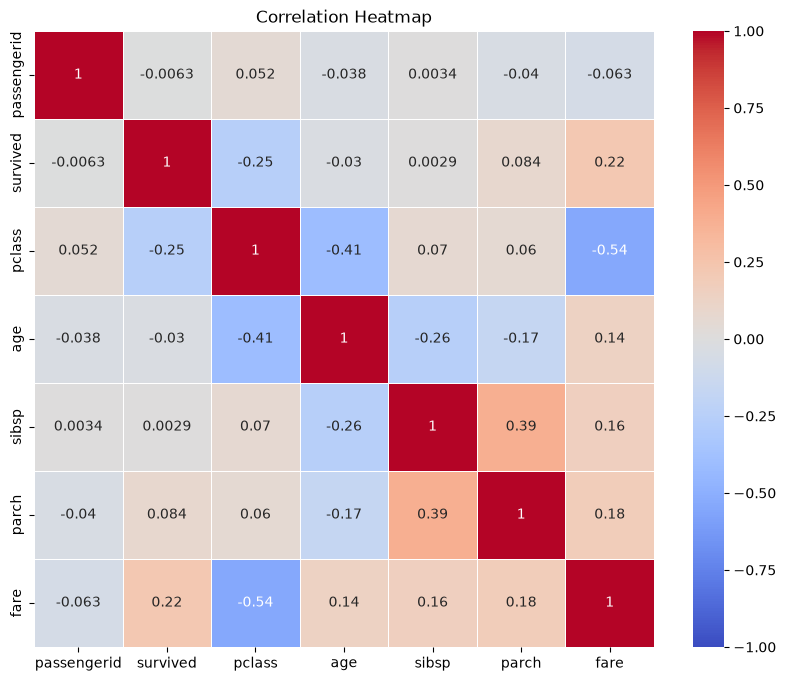

In [13]:
#상관관계 확인하기.
corr =train_num.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,          # 상관계수 숫자 표시
    cmap='coolwarm',     # 색상
    vmin=-1,
    vmax=1,              # 상관계수 범위 고정
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

In [14]:
# 상관관계가 어느정도 높아보이는것 : pcalss - age, pclass - fare, sibsp - parch
# feature-feature끼리는 어느정도 높아보이는데, feture- target은 상관관계가 낮은데..? 반대로 되어야하는거잖아?

# 클로드가 말하길. age같은 경우 아이, 노년은 생존율이 높은데 청장년층은 낮기떄문에 비선형 패턴임.그래서 해당 상관관계로는 알수가없대.
# 비슷한 경우들이 꽤 있을거임. age같은 경우도 나이대별로 나눠서 비교해야 확실할거임.
# 또한 숫자형만 있기때문에 문자형은 따로 확인해봐야함.

# Data Preprocessing

## data cleaning

In [15]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [16]:
# 결측치 확인 및 제거 
null_tr = train_train.isnull().sum()

(null_tr[null_tr > 0] / train_train.shape[0]).sort_values(ascending=False)

cabin    0.790393
age      0.183406
dtype: float64

In [17]:
null_te = train_test.isnull().sum()

(null_te[null_te > 0] / train_test.shape[0]).sort_values(ascending=False)

cabin       0.764192
age         0.235808
embarked    0.004367
dtype: float64

In [18]:
null_real_te = test.isnull().sum()

(null_real_te[null_real_te > 0] / test.shape[0]).sort_values(ascending=False)

cabin       0.753181
age         0.211196
fare        0.002545
embarked    0.002545
dtype: float64

In [19]:
# cabin 결측치가 매우 많음. 결측치를 치환할지, 컬럼을 삭제할지, 어떻게 하는게 좋을지 알아보기 위해 확인하는 작업

# 1. has_cabin 플래그 만들기 (cabin 값이 있으면 1, 없으면 0)
for tmp in [train_train, train_test, test]:
    tmp['has_cabin'] = tmp['cabin'].notna().astype(int)

# has_cabin 만들었으니 원본 cabin은 더 이상 안 씀 -> 드랍해야 함
train_train.drop(columns=['cabin'], inplace=True)
train_test.drop(columns=['cabin'], inplace=True)
test.drop(columns=['cabin'], inplace=True)

# # 2. has_cabin별 생존율 비교
# train.groupby('has_cabin')[['survived']].agg(['mean', 'count'])

# #cabin 값이 있는 그룹에서 생존율이 60프로나 나왔음. cabin 값이 없는 그룹의 생존율은 30프로. 뭔가 중요한 정보같음. 컬럼 삭제하면안될듯


In [20]:
# # 3. has_cabin이 왜 저렇게 갈리는지 — pclass 분포로 원인 확인
# pd.crosstab(train['has_cabin'], train['pclass'], normalize='index').round(3)
# # has_cabin=1인 사람들 중 몇 %가 1등석인지 보임 

# # cabin 값을 가지고 있는 사람들의 87프로가 1등석임.ㄷㄷ

In [21]:
# #우선은 cabin은 결측치 제거 안하고 해볼예정임.
# print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

# for tmp in [train, test]:
#     null_tmp = tmp.isnull().sum()
#     null_cols = null_tmp[null_tmp > 0].index

#     for col in null_cols:
#         try:
#             tmp[col] = tmp[col].fillna(train[col].mean())

#         except:
#             tmp[col] = tmp[col].fillna(train[col].mode().values[0])

# print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

In [22]:
#우선은 cabin은 결측치 제거 안하고 해볼예정임.
import numpy as np

RANDOM_STATE = 42  # 노트북 전체에서 재사용할 시드 (train_test_split, 모델 등에도 이 값 그대로 쓸 것)

print(f"before: {train_train.isnull().sum().sum()} / {train_test.isnull().sum().sum()}")

RANDOM_FILL_COLS = ['age', 'embarked','fare']  # cabin은 이번 시도에서 결측 그대로 유지

for tmp in [train_train, train_test,test]:
    for col in RANDOM_FILL_COLS:
        n_missing = tmp[col].isnull().sum()
        if n_missing == 0:
            continue
        # train 컬럼의 관측값(NaN 아닌 것)들 중에서 복원추출로 랜덤하게 뽑아 채움
        # test에도 항상 train 기준 값으로 채워야 데이터 누수가 안 생김
        fill_values = (
            train_train[col].dropna().sample(n=n_missing, replace=True, random_state=RANDOM_STATE).values
        )
        tmp.loc[tmp[col].isnull(), col] = fill_values

print(f"after: {train_train.isnull().sum().sum()} / {train_test.isnull().sum().sum()}")
# cabin은 일부러 안 채웠으니 after에도 0은 아닐 것. 남은 결측치는 모두 cabin 컬럼의 결측치임.

before: 126 / 55
after: 0 / 0


In [23]:
for tmp in [train_train, train_test, test]:
    tmp['title'] = tmp['name'].str.extract(r',\s*([^\.]+)\.')
    # Mr/Miss/Mrs/Master 외 희귀 title(Rev, Dr, Col 등)은 표본이 1~6개뿐이라
    # 그대로 두면 카테고리만 늘어나고 과적합 위험 있음 -> 'Rare'로 묶는 걸 권함
    tmp['title'] = tmp['title'].where(
        tmp['title'].isin(['Mr', 'Miss', 'Mrs', 'Master']), 'Rare'
    )

train_train.drop(columns=['name'], inplace=True)
train_test.drop(columns=['name'], inplace=True)
test.drop(columns=['name'], inplace=True)

In [24]:
for tmp in [train_train, train_test,test]:
    tmp['ticket_group_size'] = tmp.groupby('ticket')['ticket'].transform('count')

train_train.drop(columns=['ticket'], inplace=True)
train_test.drop(columns=['ticket'], inplace=True)
test.drop(columns=['ticket'], inplace=True)

In [25]:
for tmp in [train_train, train_test,test]:
    tmp['family_size'] = tmp['sibsp'] + tmp['parch'] + 1

In [26]:
test_passenger_ids = test['passengerid'].copy() ## 제출 파일 만들 때 쓸 용도로 미리 보관

train_train.drop(columns=['passengerid'], inplace=True)
train_test.drop(columns=['passengerid'], inplace=True)
test.drop(columns=['passengerid'], inplace=True)

In [27]:
# for tmp in [train_train, train_test, test]:
#     tmp['cabin'] = tmp['cabin'].str[0]  # 'Missing'은 그대로 'M'이 됨 — 괜찮음 (별도 카테고리로 유지)

In [28]:
train_train.columns

Index(['survived', 'pclass', 'gender', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'has_cabin', 'title', 'ticket_group_size', 'family_size'],
      dtype='str')

In [29]:
train_train.describe()

,survived,pclass,age,sibsp,parch,fare,has_cabin,ticket_group_size,family_size
count,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000
mean,0.378457,2.288210,29.900771,0.491994,0.331878,30.963918,0.209607,1.538574,1.823872
std,0.485356,0.828549,14.826415,0.992469,0.740668,45.802139,0.407325,1.013558,1.460704
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.910400,0.000000,1.000000,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,29.125000,0.000000,2.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,7.000000,11.000000


In [ ]:
#언밸런스하니까 오버샘플링 해볼거임. 오버 샘플링은 각각 거리를 계산할 수 있어야하잖아? 그럼 일단 수치형이어야할거임.그러려면 인코딩도 당연히해야겠지? 어떤데이터를 써야할지 골라보자.
x_train = train_train.drop(columns=['survived'])
x_test = train_test.drop(columns=['survived'])

y_train = train_train['survived']   # SMOTE에 같이 넣을 target, 따로 저장
y_test = train_test['survived']

x_train_number = train_train.select_dtypes(include=np.number)
x_train_str = train_train.select_dtypes(exclude=np.number)

x_test_number =train_test.select_dtypes(include=np.number)
x_test_str = train_test.select_dtypes(exclude=np.number)

encoder = ce.OneHotEncoder(use_cat_names=True)

encoder.fit(x_train_str)                 # 학습은 train만

encoded_col = encoder.transform(x_train_str)
encoded_col_test = encoder.transform(x_test_str)  # 변환은 train/test 둘 다

x_train_final = pd.concat([x_train_number, encoded_col], axis = 1)
x_test_final = pd.concat([x_test_number, encoded_col_test], axis = 1)


In [31]:
X_samp, y_samp = SMOTE(random_state=4).fit_resample(x_train_final, y_train)

In [40]:
train_train.columns

Index(['survived', 'pclass', 'gender', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'has_cabin', 'title', 'ticket_group_size', 'family_size'],
      dtype='str')

# Modeling


## Check Dataset before Modeling

In [32]:
for col in CAT_COLS:
    all_categories = pd.concat(
        [train_train[col], train_test[col], test[col]]
    ).astype('category').cat.categories

    for tmp in [train_train, train_test, test]:
    
        tmp[col] = pd.Categorical(tmp[col], categories=all_categories)

In [33]:
#모델링 객체 만들어짐.
modeling = Modeling(
    x_tr=train_train.drop(['survived'], axis=1),
    y_tr=train_train['survived']
)

In [34]:
modeling.fit_evaluation(
    x_te = train_test.drop(['survived'], axis=1),
    y_te = train_test['survived']
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [35]:
modeling.get_best_model()

{'model': LGBMClassifier(verbose=-1),
 'model_name': 'LGBMClassifier',
 'hpo': {'verbose': -1},
 'train_score': np.float64(0.9969014591965412),
 'y_pre_te': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
        0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
        1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
        1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
        0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
        0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
        0, 0, 0, 1, 0, 1, 1, 0, 0]),
 'test_score': np.float64(0.9033582696373395),
 'score_type': 'auc'

# Evaluation

In [36]:
print(f'훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}')

훈련용 평가지표: 0.9969014591965412 / 테스트용 평가지표: 0.9033582696373395


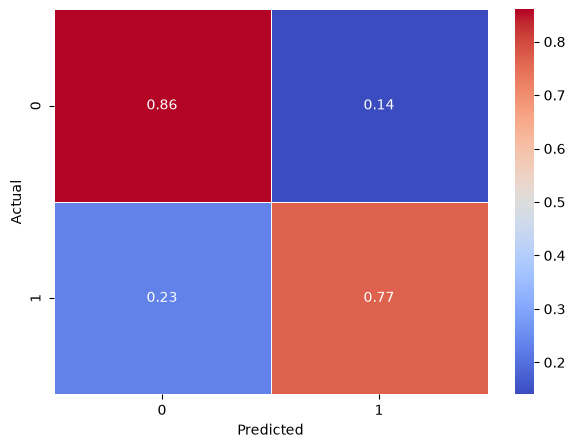

In [37]:
#얘도 함수로 만드는게 낫겠찌?

from sklearn.metrics import confusion_matrix

norm_conf_mx = confusion_matrix(train_test['survived'], modeling.get_best_model()['y_pre_te'], normalize="true")

plt.figure(figsize=(7,5))

sns.heatmap(norm_conf_mx, annot=True, cmap="coolwarm", linewidth=0.5)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

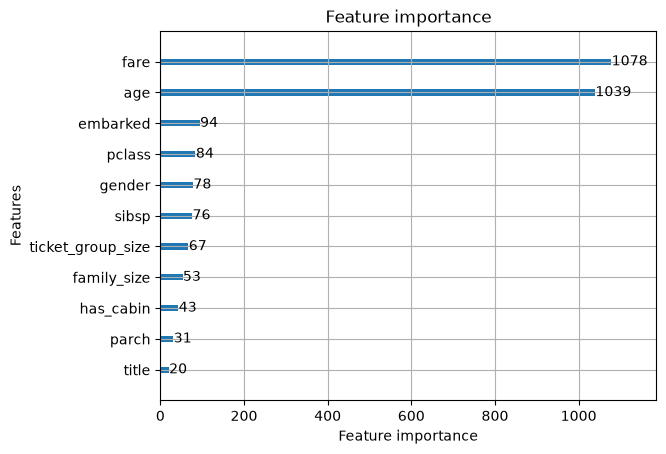

In [38]:

from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# Submission

In [ ]:
import os
import pandas as pd

EXPERIMENT_LOG_PATH = r"C:\dev\kaggle_competition\titanic_real\record\experiment_log.csv"  # 실제 위치 다르면 여기만 수정
SUBMISSION_DIR = r"C:\dev\kaggle_competition\titanic_real\submission"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

# experiment_log.csv에 기록된 마지막 attempt_no + 1을 다음 시도 번호로 사용
if os.path.exists(EXPERIMENT_LOG_PATH):
    log_df = pd.read_csv(EXPERIMENT_LOG_PATH)
    next_attempt_no = int(log_df['attempt_no'].max()) + 1 if len(log_df) > 0 else 1
else:
    next_attempt_no = 1  # 로그 파일이 아직 없으면 1번부터 시작

survived_proba = modeling.predict_by_best_model(test)

submission = pd.DataFrame({
    'passengerid': test_passenger_ids,
    'survived': survived_proba
})

submission_filename = f"submission_attempt{next_attempt_no}.csv"
submission_path = os.path.join(SUBMISSION_DIR, submission_filename)
submission.to_csv(submission_path, index=False)

print(f"이번 시도 번호: {next_attempt_no}")
print(f"저장 완료: {submission_path}")
submission.head()

print(f"노트북 파일명: {CURRENT_NOTEBOOK_FILENAME}")
print(f"이번 시도 번호: {next_attempt_no}")
print(f"저장 완료: {submission_path}")

이번 시도 번호: 1
저장 완료: C:\dev\kaggle_competition\titanic_real\submission\submission_attempt1.csv


,passengerid,survived
0,916,0.971566
1,917,0.955524
2,918,0.702185
3,919,0.065162
4,920,0.881573
